# Time-Dependent Coupling Depth Subduction Zone Setup

## Preamble

Let's start by adding the path to the modules in the `python` folder to the system path (so we can find the our custom modules).

In [1]:
import sys, os, shutil
basedir = ''
if "__file__" in globals(): basedir = os.path.dirname(__file__)
sys.path.insert(0, os.path.join(basedir, os.path.pardir, os.path.pardir, 'python'))

Let's also load the module generated by the previous notebooks to get access to the parameters and functions defined there.

In [2]:
from fenics_sz.sz_problems.sz_problem import StokesSolverNest, TemperatureSolver
from fenics_sz.sz_problems.sz_tdep_dislcreep import TDDislSubductionProblem

Then let's load all the required modules at the beginning.

In [3]:
import dolfinx as df
import numpy as np
import scipy as sp
import pathlib
output_folder = pathlib.Path(os.path.join(basedir, "output"))
output_folder.mkdir(exist_ok=True, parents=True)

In [60]:
class TDCDDislSubductionProblem(TDDislSubductionProblem):
    def members(self):
        # initialize the standard members in the parent class
        super().members()

        # add additional parameter for time-dependent coupling
        self.allowed_input_parameters += ["cd0", "cdf", "dcd", "tc0", "tcf"]
        self.required_parameters += ["cd0", "cdf", "dcd", "tc0", "tcf"]
        self.required_parameters += ["As"] # this was previously only required if oceanic

        self.cd0 = None # initial coupling depth
        self.cdf = None # final coupling depth
        self.dcd = None # partial coupling depth offset
        self.tc0 = None # time for initial coupling (in Myr)
        self.tcf = None # time for full coupling (in Myr)

        self.t_Myr = 0.0 # current dimensional time (in Myr)
        self.tdep_bcs = ['vw_slabtop'] # one time-dependet boundary condition

    # Overload the vw_slabtop method
    def vw_slabtop(self, x):
        """
        Return the wedge velocity on the slab surface
        """
        # work out the current coupling depth from the time
        # FIXME: this really should be stored
        cd = min(max(self.cd0, self.cd0 + (self.cdf - self.cd0)/(self.tcf - self.tc0)*(self.t_Myr - self.tc0)), self.cdf)
        pcd = cd - self.dcd # current partial coupling depth
        v = np.empty((self.gdim, x.shape[1]))
        for i in range(x.shape[1]):
            v[:,i] = min(max(-(x[1,i]+pcd)/self.dcd, 0.0), 1.0)*self.Vs_nd*self.geom.slab_spline.unittangentx(x[0,i])
        return v
    
    def T_trench(self, x):
        """
        Return temperature at the trench. Use GDH1 from Stein&Stein, Nature, 1992
        """
        np.set_printoptions(threshold=500)
        # a few GDH1 parameters
        pi=3.141592653
        pi2=pi*pi
        H_GDH1  = 95.0 # scale depth is 95 km
        T0_GDH1 = 1450.0 # full T in C at base of lithosphere
        T0_GDH1_ma = T0_GDH1 - 0.3*H_GDH1 # T in C at base of lithosphere minus adiabat
        kappa_GDH1 = 3.1/(3300.0*1250.0)
        v_GDH1 = 0.01/(365.25*3600*24) # 1 cm/yr model velocity in SI
        x_GDH1 = 10*self.A # in m distance from trench assuming 1 cm/yr speed
        x_norm = x_GDH1/H_GDH1 # normalized distance
        Pe_GDH1 = v_GDH1*H_GDH1*1e3/(2*kappa_GDH1) # Peclet number
        # print(Pe_GDH1,self.A)
        # bathymetry:
        deltazsurface = np.minimum(np.maximum(self.deltaztrench*(1.0 - x[0,:]/max(self.deltaxcoast, np.finfo(float).eps)), 0.0), self.deltaztrench)

        # build T_GDH1 with adiabat assumed
        z_here  = -(x[1,:]+deltazsurface)
        #print(z_here.shape)
        #print(z_here)
        ### z_here = np.linspace(0,100,num=101)
        z_norm = z_here / H_GDH1
        #T_GDH1 = T0_GDH1*z_norm + 0.3*z_here # linear approximation for t->/inf
        GDH1=z_norm
        #GDH1=np.where(z_here<=H_GDH1,z_norm,0.0)
        for n in range(1,100):
            c = 2.0/(n*np.pi)
            beta = np.sqrt(Pe_GDH1*Pe_GDH1 + n*n*pi2)-Pe_GDH1
            GDH1=GDH1+c*np.exp(-beta*x_norm)*np.sin(n*pi*z_norm)
        T_GDH1=GDH1*T0_GDH1
        # T_GDH1 = np.where(z_here<=H_GDH1,T0_GDH1*GDH1,0.0)
        #print(T_GDH1)
        # limit T to adiabat for z_here<=T_GDH1 (to avoid issues near H_GDH1)
        # T_GDH1 = np.where(T_GDH1>T0_GDH1_ma+0.3*z_here,T0_GDH1_ma+0.3*z_here,T_GDH1)
        # full GDH1 with adiabat
        T_GDH1 = np.where(z_here<=H_GDH1,T_GDH1,T0_GDH1+0.3*(z_here-H_GDH1))
        #T_GDH1 = np.where(z_here>=H_GDH1,T0_GDH1+0.3*(z_here-H_GDH1),T_GDH1)
        #T_GDH1
        return self.Ts + T_GDH1 - z_here*0.3
# ! GDH1: From Stein and Stein, Nature 1992 with thermal parameters for
# ! mantle as
# ! in Syracuse et al. 2010, Wada and Wang, 2009.
# ! z in km, age in Myr.
# real(kind=8) function GDH1(z,age)
# implicit none
# real(kind=8) :: z,age,x
# ! note: a in km
# real(kind=8),parameter :: Cp=1250,a=95,Tm=1450.0,rhom=3300,k=3.1,dif=k/(rhom*Cp),v=0.01/(365.25*3600*24)
# real(kind=8) :: beta,c,R,xa,za
# real(kind=8),parameter :: pi=3.141592653,pi2=pi*pi
# integer :: n,Nmax=100
#
# if (z>95) then
#    GDH1=Tm+0.3*(z-95)
#    return
# endif
#
# x=10*age ! in m assuming 10 mm/yr
# R=v*a*1e3/(2*dif) ! Peclet number (R??)
# xa=x/a  ! normalized distance
# za=z/a  ! normalized depth
# GDH1=za
# do n=1,Nmax
#    c=2_8/(n*pi)
#    beta=sqrt(R*R+n*n*pi2)-R
#    GDH1=GDH1+c*exp(-beta*xa)*sin(n*pi*za)
# enddo
# GDH1=Tm*GDH1
#
# GDH1=min(1421.5+0.3*z,GDH1)
#
# end function GDH1


# 

## 43 Izu example with a time-dependent coupling depth

### Preamble

Set some path information.

Loading everything we need from `sz_problem` and also set our default plotting and output preferences.

In [61]:
import fenics_sz.utils
from fenics_sz.sz_problems.sz_params import allsz_params, default_params
from fenics_sz.sz_problems.sz_slab import create_slab, plot_slab
from fenics_sz.sz_problems.sz_geometry import create_sz_geometry
import numpy as np
import dolfinx as df
import pyvista as pv
import pathlib
import copy
import matplotlib.pyplot as pl
output_folder = pathlib.Path(os.path.join(basedir, "output"))
output_folder.mkdir(exist_ok=True, parents=True)

### Parameters

We first select the name and resolution scale, `resscale` and target Courant number `cfl` of the model.

```{admonition} Resolution
By default the resolution (both spatial and temporal) is low to allow for a quick runtime and smaller website size.  If sufficient computational resources are available set a lower `resscale` and a lower `cfl` to get higher spatial and temporal resolutions respectively. This is necessary to get results with sufficient accuracy for scientific interpretation.
```


In [72]:
name = "43_Izu"
resscale = 1
cfl      = 3.0

Then load the remaining parameters from the global suite.

In [73]:
szdict = allsz_params[name]
print("{}:".format(name))
print("{:<20} {:<10}".format('Key','Value'))
print("-"*85)
for k, v in allsz_params[name].items():
    if v is not None and k not in ['z0', 'z15']: print("{:<20} {}".format(k, v))

43_Izu:
Key                  Value     
-------------------------------------------------------------------------------------
coast_distance       235
extra_width          12.5
lc_depth             30
io_depth             184
dirname              43_Izu
As                   1.0
Ac                   70.0
A                    100
sztype               oceanic
Vs                   45.6
xs                   [0, 32.0, 86.0, 138.0, 178.1, 180.8, 199.0, 268.0, 327.5]
ys                   [-6, -15.0, -30.0, -50.0, -80.0, -82.5, -100.0, -175.0, -240.0]


Modify the age of subduction to 52 Myr:

In [74]:
szdict['As'] = 1.0
szdict['A']  = 100

### Setup

Setup a slab.

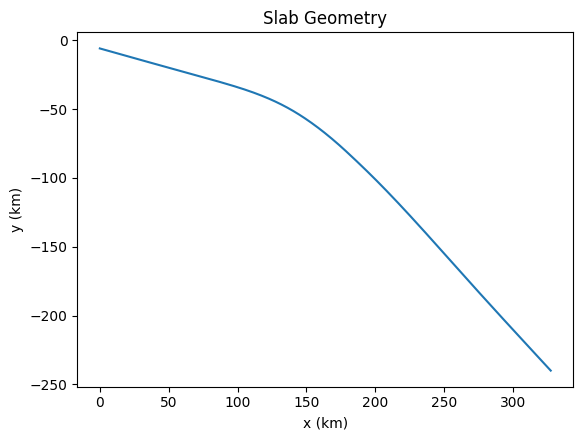

In [75]:
slab = create_slab(szdict['xs'], szdict['ys'], resscale, szdict['lc_depth'])
_ = plot_slab(slab)

Create the subduction zome geometry around the slab.

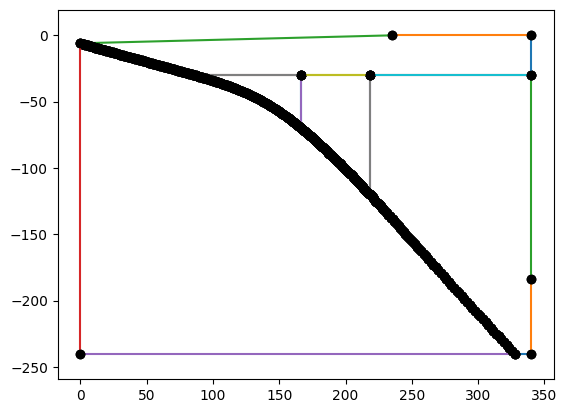

In [76]:
geom = create_sz_geometry(slab, resscale, szdict['sztype'], szdict['io_depth'], szdict['extra_width'], 
                             szdict['coast_distance'], szdict['lc_depth'], szdict['uc_depth'])
_ = geom.plot()

Finally, declare the `TDDislSubductionProblem` problem class using the dictionary of parameters.

In [77]:
sz = TDCDDislSubductionProblem(geom, **szdict, 
                               cd0=30, cdf=80, dcd=default_params['coupling_depth_range'],
                               tc0=0.0, tcf=szdict['As'])

### Solve

Solve using a dislocation creep rheology.

In [78]:
# save period
save_period = 1.0

# Select the timestep based on the approximate target Courant number
dt = cfl*resscale/szdict['Vs']
# Reduce the timestep to get an integer number of timesteps per save period
dt = save_period/np.ceil(save_period/dt)

solutions = sz.solve(szdict['As'], dt, theta=0.5, rtol=1.e-1, verbosity=2, save_period=save_period)

Entering timeloop with 16 steps (dt = 0.0625 Myr, final time = 1 Myr)
Step:      0, Times:         0 ->    0.0625 Myr
Step:      1, Times:    0.0625 ->     0.125 Myr
Step:      2, Times:     0.125 ->    0.1875 Myr
Step:      3, Times:    0.1875 ->      0.25 Myr
Step:      4, Times:      0.25 ->    0.3125 Myr
Step:      5, Times:    0.3125 ->     0.375 Myr
Step:      6, Times:     0.375 ->    0.4375 Myr
Step:      7, Times:    0.4375 ->       0.5 Myr
Step:      8, Times:       0.5 ->    0.5625 Myr
Step:      9, Times:    0.5625 ->     0.625 Myr
Step:     10, Times:     0.625 ->    0.6875 Myr
Step:     11, Times:    0.6875 ->      0.75 Myr
Step:     12, Times:      0.75 ->    0.8125 Myr
Step:     13, Times:    0.8125 ->     0.875 Myr
Step:     14, Times:     0.875 ->    0.9375 Myr
Step:     15, Times:    0.9375 ->         1 Myr
Finished timeloop after 16 steps (final time = 1 Myr)


### Plot

Plot the solution at the finish time.

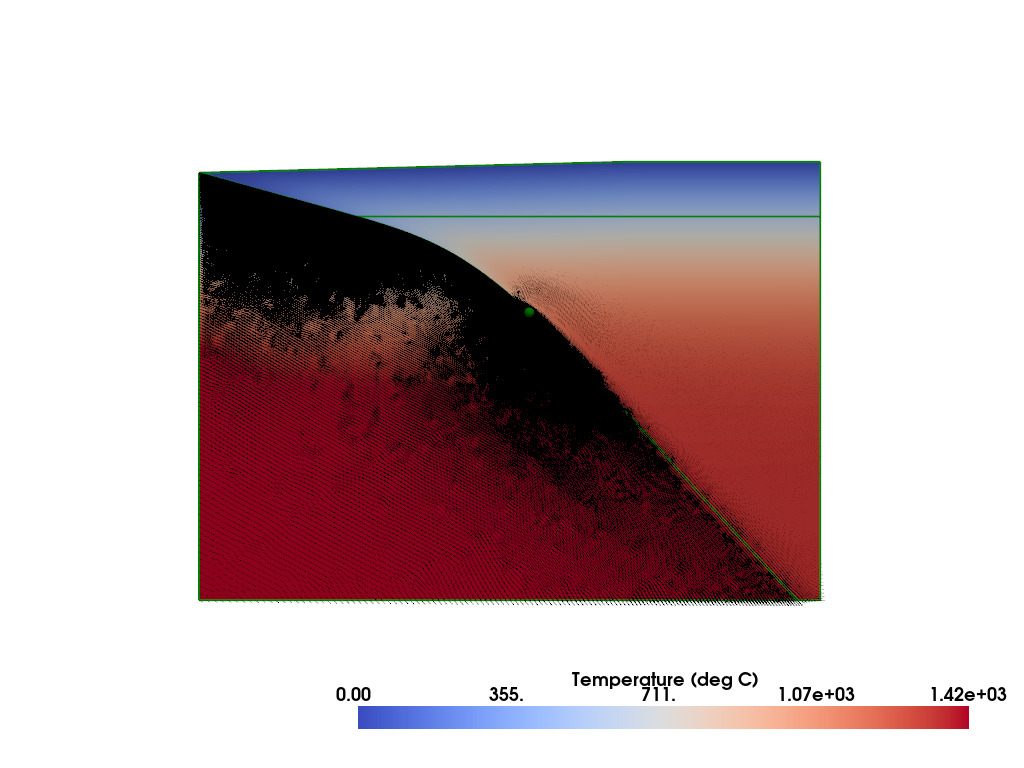

In [79]:
plotter = pv.Plotter()
fenics_sz.utils.plot.plot_scalar(sz.T_i, plotter=plotter, scale=sz.T0, gather=True, cmap='coolwarm', scalar_bar_args={'title': 'Temperature (deg C)', 'bold':True})
fenics_sz.utils.plot.plot_vector_glyphs(sz.vw_i, plotter=plotter, gather=True, factor=0.1, color='k', scale=fenics_sz.utils.mps_to_mmpyr(sz.v0))
fenics_sz.utils.plot.plot_vector_glyphs(sz.vs_i, plotter=plotter, gather=True, factor=0.1, color='k', scale=fenics_sz.utils.mps_to_mmpyr(sz.v0))
geom.pyvistaplot(plotter=plotter, color='green', width=2)
cdpt = slab.findpoint('Slab::FullCouplingDepth')
fenics_sz.utils.plot.plot_points([[cdpt.x, cdpt.y, 0.0]], plotter=plotter, render_points_as_spheres=True, point_size=10.0, color='green')
fenics_sz.utils.plot.plot_show(plotter)
fenics_sz.utils.plot.plot_save(plotter, output_folder / "{}_td_solution_resscale_{:.2f}_cfl_{:.2f}.png".format(name, resscale, cfl,))

Save it to disk so that it can be examined with other visualization software (e.g. [Paraview](https://www.paraview.org/)).

In [80]:
filename = output_folder / "{}_td_solution_resscale_{:.2f}_cfl_{:.2f}.bp".format(name, resscale, cfl,)
with df.io.VTXWriter(sz.mesh.comm, filename, [sz.T_i, sz.vs_i, sz.vw_i]) as vtx:
    vtx.write(0.0)
# zip the .bp folder so that it can be downloaded from jupyter lab
shutil.make_archive(str(filename), 'zip', root_dir=str(filename.parent), base_dir=str(filename.name))

'/root/shared/notebooks/05_applications/output/43_Izu_td_solution_resscale_1.00_cfl_3.00.bp.zip'

### Plot slab temperatures and save slabpaths over time

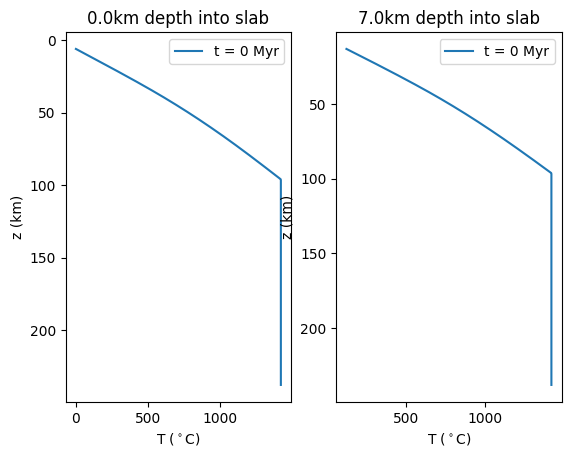

In [81]:
# set up a figure
fig, axs = pl.subplots(1,2)
# first output solution at trench
slab = copy.deepcopy(sz.geom.slab_spline)
trenchpoints = np.array([[0.0, curve.points[0].y, 0.0] for curve in slab.interpcurves])
cinds, cells = fenics_sz.utils.mesh.get_cell_collisions(trenchpoints, sz.mesh)
T = solutions[0]['T']
Ttrench = T.eval(trenchpoints, cells)[:,0]
with open(output_folder / 'TrenchT.txt', 'w') as f:
        np.savetxt(f, 
                    np.column_stack((trenchpoints[:,0], trenchpoints[:,1], Ttrench)), 
                    delimiter=' ')

for d, depth in enumerate([0.0, 7.0]):
    # get some points along the slab
    slab = copy.deepcopy(sz.geom.slab_spline)
    slab.translatenormalandcrop(-depth)
    slabpoints = np.array([[curve.points[0].x, curve.points[0].y, 0.0] for curve in slab.interpcurves])
    cinds, cells = fenics_sz.utils.mesh.get_cell_collisions(slabpoints, sz.mesh)

    for sol in solutions[::5]: # remove [::5] to get them all
        t = sol['t']
        T = sol['T']
        # plot the slab temperatures
        Tslab = T.eval(slabpoints, cells)[:,0]
        axs[d].plot(Tslab, -slabpoints[:,1], label='t = {:.0f} Myr'.format(t))

        mode = 'a'
        if d == 0: mode = 'w'
        with open(output_folder / 'slab_temperatures_{:.0f}.txt'.format(t), mode) as f:
            np.savetxt(f, 
                    np.column_stack((slabpoints[:,0], slabpoints[:,1], np.ones(len(slabpoints[:,1]))*depth, Tslab)), 
                    delimiter=' ')
    
    axs[d].set_xlabel('T ($^\circ$C)')
    axs[d].set_ylabel('z (km)')
    axs[d].set_title('{}km depth into slab'.format(depth,))
    axs[d].legend()
    axs[d].invert_yaxis()


In [59]:
# intersection of crust and slab
crustpt = sz.geom.slab_spline.intersecty(-7.0)
# intersection of aribtrary x and slab
x = 200
arbpt = sz.geom.slab_spline.intersectx(x)
crustpt[0], crustpt[1], arbpt[0], arbpt[1]

(np.float64(3.533820292591435), -7.0, 200, -100.99891285059469)

In [17]:
sz.geom.coast_distance, sz.deltaxcoast

(235, 235)

In [18]:
sz.geom.trench_y, sz.deltaztrench

(-6, 6)

In [19]:
x = 135
np.minimum(np.maximum(sz.deltaztrench*(1.0 - x/max(sz.deltaxcoast, np.finfo(float).eps)), 0.0), sz.deltaztrench)

np.float64(2.553191489361702)